OVERALL PRICE SUMMARY STATS:
count    2557.000000
mean      360.751271
std       226.659288
min        10.000000
25%       170.000000
50%       310.000000
75%       460.000000
max      2909.000000
Name: price, dtype: float64

PRICE SUMMARY STATS BY DAY TYPE (False = Ordinary, True = Festival):
              count        mean         std   min    25%    50%    75%     max
is_festival                                                                   
False        2424.0  356.429455  224.887203  10.0  170.0  310.0  420.0  2909.0
True          133.0  439.518797  244.657788  70.0  230.0  405.0  620.0   820.0


C:\Users\ASUS\AppData\Local\Temp\ipykernel_18404\1395758019.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


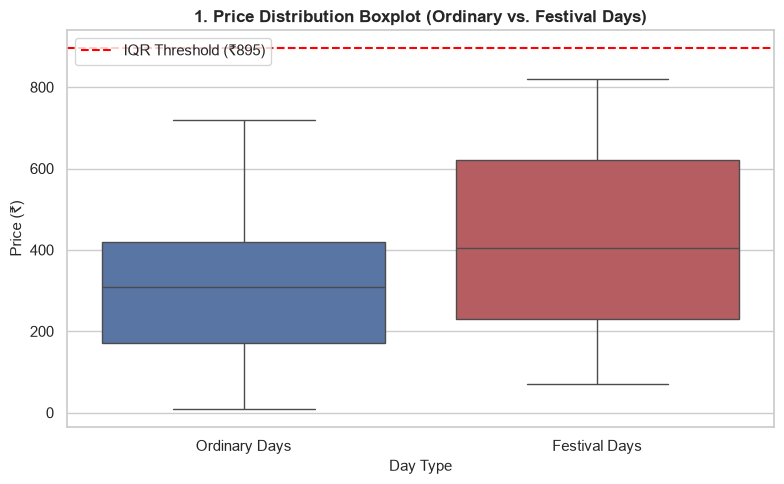

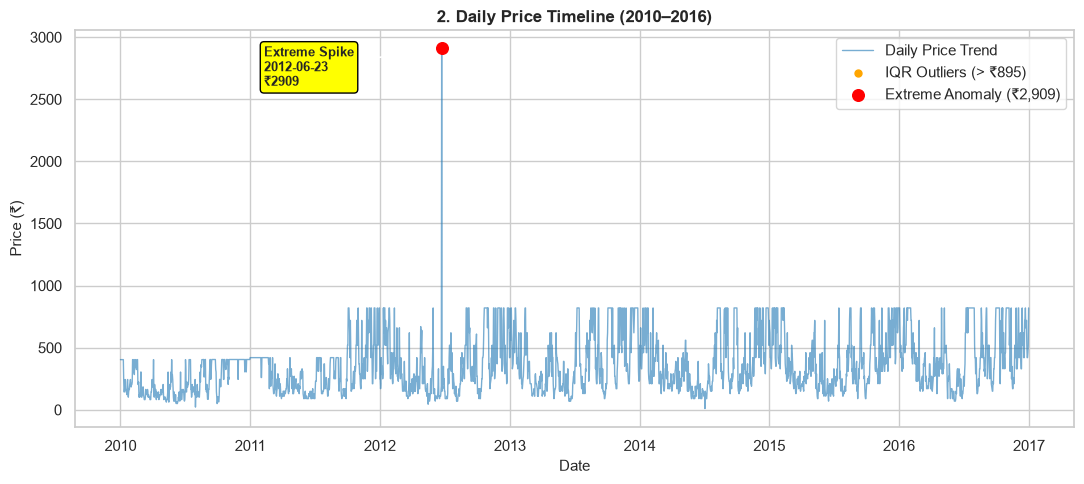

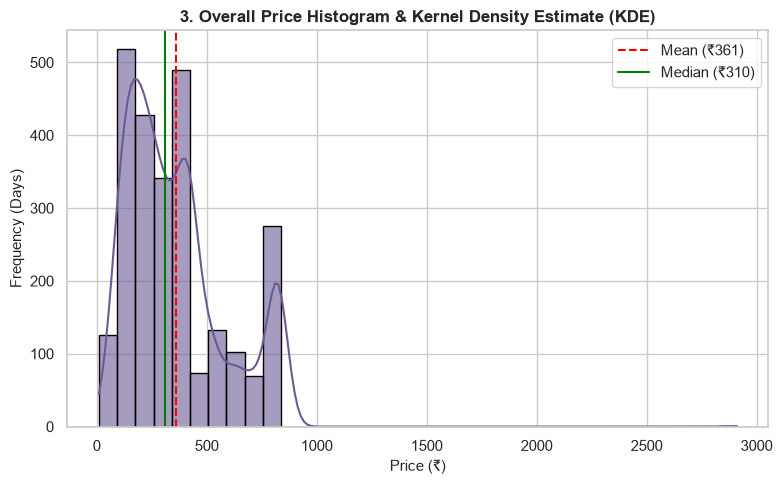

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Data and Handle Duplicate Festival Rows
CSV_PATH = r"C:\Project\data\processed\clean_prices_festivals_2010_2016.csv"
df_raw = pd.read_csv(CSV_PATH)
df_raw['DATE'] = pd.to_datetime(df_raw['DATE'])

df_clean = df_raw.groupby('DATE').agg({
    'festival_name': lambda x: ' | '.join(sorted(x.dropna().astype(str).unique())) if len(x.dropna()) > 0 else None,
    'price': 'first'
}).reset_index()

df_clean['is_festival'] = df_clean['festival_name'].notna()

# 2. Calculate & Print EDA Summary Statistics
overall_stats = df_clean['price'].describe(percentiles=[0.25, 0.50, 0.75])
by_type_stats = df_clean.groupby('is_festival')['price'].describe(percentiles=[0.25, 0.50, 0.75])

print("="*50)
print("OVERALL PRICE SUMMARY STATS:")
print("="*50)
print(overall_stats)

print("\n" + "="*50)
print("PRICE SUMMARY STATS BY DAY TYPE (False = Ordinary, True = Festival):")
print("="*50)
print(by_type_stats)

# Outlier Bounds Calculation
Q1 = df_clean['price'].quantile(0.25)
Q3 = df_clean['price'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

outliers = df_clean[df_clean['price'] > upper_bound]
anomaly = df_clean[df_clean['price'] > 2000]

sns.set_theme(style="whitegrid")

# -------------------------------------------------------------------------
# GRAPH 1: Clean Boxplot (No Black Outlier Dots)
# -------------------------------------------------------------------------
plt.figure(figsize=(8, 5))
sns.boxplot(
    x='is_festival', 
    y='price', 
    data=df_clean, 
    palette=['#4c72b0', '#c44e52'],
    showfliers=False  # Hides individual black outlier dots
)
plt.axhline(upper_bound, color='red', linestyle='--', linewidth=1.5, label=f'IQR Threshold (₹{upper_bound:.0f})')
plt.xticks([0, 1], ['Ordinary Days', 'Festival Days'], fontsize=11)
plt.title('1. Price Distribution Boxplot (Ordinary vs. Festival Days)', fontsize=12, fontweight='bold')
plt.xlabel('Day Type', fontsize=11)
plt.ylabel('Price (₹)', fontsize=11)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

# -------------------------------------------------------------------------
# GRAPH 2: Timeline Plot with Anomaly Callout
# -------------------------------------------------------------------------
plt.figure(figsize=(11, 5))
plt.plot(df_clean['DATE'], df_clean['price'], color='#1f77b4', alpha=0.6, linewidth=1, label='Daily Price Trend')
plt.scatter(outliers['DATE'], outliers['price'], color='orange', s=25, zorder=4, label=f'IQR Outliers (> ₹{upper_bound:.0f})')
plt.scatter(anomaly['DATE'], anomaly['price'], color='red', s=70, zorder=5, label='Extreme Anomaly (₹2,909)')

for _, row in anomaly.iterrows():
    plt.annotate(
        f"Extreme Spike\n{row['DATE'].strftime('%Y-%m-%d')}\n₹{row['price']}",
        xy=(row['DATE'], row['price']),
        xytext=(row['DATE'] - pd.Timedelta(days=500), row['price'] - 300),
        arrowprops=dict(facecolor='black', arrowstyle='->', lw=1.2),
        fontsize=9,
        fontweight='bold',
        bbox=dict(boxstyle="round,pad=0.3", fc="yellow", ec="black", lw=1)
    )

plt.title('2. Daily Price Timeline (2010–2016)', fontsize=12, fontweight='bold')
plt.xlabel('Date', fontsize=11)
plt.ylabel('Price (₹)', fontsize=11)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

# -------------------------------------------------------------------------
# GRAPH 3: Price Histogram & Kernel Density Estimate (KDE)
# -------------------------------------------------------------------------
plt.figure(figsize=(8, 5))
sns.histplot(df_clean['price'], kde=True, bins=35, color='#6b5b95', edgecolor='black', alpha=0.6)
plt.axvline(df_clean['price'].mean(), color='red', linestyle='--', linewidth=1.5, label=f"Mean (₹{df_clean['price'].mean():.0f})")
plt.axvline(df_clean['price'].median(), color='green', linestyle='-', linewidth=1.5, label=f"Median (₹{df_clean['price'].median():.0f})")
plt.title('3. Overall Price Histogram & Kernel Density Estimate (KDE)', fontsize=12, fontweight='bold')
plt.xlabel('Price (₹)', fontsize=11)
plt.ylabel('Frequency (Days)', fontsize=11)
plt.legend()
plt.tight_layout()
plt.show()



ANNUAL EDA SUMMARY STATISTICS (PRICE BY YEAR & DAY TYPE)
 Year      Day Type  count       mean  median        std  min  max
 2010 Festival Days     20 301.300000   404.0 123.407370  102  405
 2010 Ordinary Days    345 236.437681   204.0 128.284260   22  405
 2011 Festival Days     18 371.666667   335.0 242.735634   90  820
 2011 Ordinary Days    347 310.115274   270.0 181.032646   90  820
 2012 Festival Days     20 417.000000   300.0 270.381796   90  820
 2012 Ordinary Days    346 353.537572   275.0 263.202551   45 2909
 2013 Festival Days     19 527.894737   520.0 288.551535   70  820
 2013 Ordinary Days    346 397.485549   330.0 238.602893   70  820
 2014 Festival Days     19 456.842105   330.0 231.901623  150  820
 2014 Ordinary Days    346 367.630058   290.0 223.798931   10  820
 2015 Festival Days     19 475.789474   420.0 250.606282  130  820
 2015 Ordinary Days    346 384.653179   330.0 216.531340   70  820
 2016 Festival Days     18 536.111111   520.0 217.178129  170  820
 2016

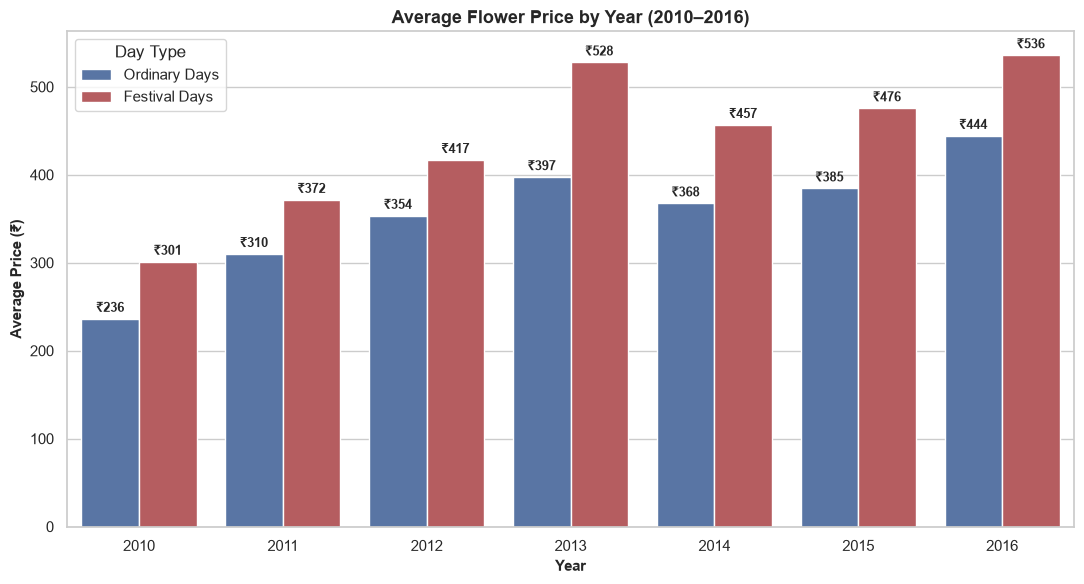

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load and Clean Dataset
CSV_PATH = r"C:\Project\data\processed\clean_prices_festivals_2010_2016.csv"
df_raw = pd.read_csv(CSV_PATH)
df_raw['DATE'] = pd.to_datetime(df_raw['DATE'])

df_clean = df_raw.groupby('DATE').agg({
    'festival_name': lambda x: ' | '.join(sorted(x.dropna().astype(str).unique())) if len(x.dropna()) > 0 else None,
    'price': 'first'
}).reset_index()

df_clean['is_festival'] = df_clean['festival_name'].notna()
df_clean['Day Type'] = df_clean['is_festival'].map({False: 'Ordinary Days', True: 'Festival Days'})
df_clean['Year'] = df_clean['DATE'].dt.year

# 2. Print Summary Statistics per Year and Day Type
yearly_stats = df_clean.groupby(['Year', 'Day Type'])['price'].agg(
    ['count', 'mean', 'median', 'std', 'min', 'max']
).reset_index()

print("=" * 70)
print("ANNUAL EDA SUMMARY STATISTICS (PRICE BY YEAR & DAY TYPE)")
print("=" * 70)
print(yearly_stats.to_string(index=False))

# 3. Plot Average Price by Year (X-axis = Years, Y-axis = Price in ₹)
sns.set_theme(style="whitegrid")
plt.figure(figsize=(11, 6))

ax = sns.barplot(
    data=df_clean,
    x='Year',
    y='price',
    hue='Day Type',
    palette={'Ordinary Days': '#4c72b0', 'Festival Days': '#c44e52'},
    estimator=np.mean,
    errorbar=None
)

# Customize title and axis labels
plt.title('Average Flower Price by Year (2010–2016)', fontsize=13, fontweight='bold')
plt.xlabel('Year', fontsize=11, fontweight='bold')
plt.ylabel('Average Price (₹)', fontsize=11, fontweight='bold')
plt.legend(title='Day Type', loc='upper left')

# Annotate exact money values on top of each bar
for p in ax.patches:
    height = p.get_height()
    if not np.isnan(height) and height > 0:
        ax.annotate(
            f'₹{height:.0f}',
            (p.get_x() + p.get_width() / 2., height),
            ha='center', va='bottom',
            fontsize=9, fontweight='bold', xytext=(0, 3),
            textcoords='offset points'
        )

plt.tight_layout()
plt.show()